In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [27]:
# read in the CSV
path = 'E:/Central Valley Fog/CV_rows_cleaned.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_cleaned.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

              STATION  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
0                         0.0            160.00  1941     12    1     0   
1                         0.0            160.

In [4]:
# read in station names CSV
path = 'E:/Central Valley Fog/station_names.csv'
if os.path.exists(path):
    station_names = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/station_names.csv'
    station_names = pd.read_csv(path, low_memory = False)

print(station_names)

     STATION_ID                                     STATION  BEGIN_DATE  \
0   USW00023155                              BAKERSFIELD AP  1927-12-31   
1   USW00093216                                   BEALE AFB  1959-06-30   
2   USI0000KC83                                       BYRON  2017-08-30   
3   USL000CQUC1                                   CARQUINEZ  2016-02-23   
4   USW00023203                                  CASTLE AFB  1941-12-31   
5   USW00093203                    CHICO ARMY FLYING SCHOOL  1942-05-05   
6   USW00023254                      CONCORD BUCHANAN FIELD  1968-12-31   
7   USL000DPXC1                   DAVIS POINT SAN PABLO BAY  2011-09-09   
8   USI0000KDLO                                 DELANO MUNI  2017-01-05   
9   USW00053125                                      FRESNO  1892-12-31   
10  USW00023167                 FRESNO CHANDLER DOWNTOWN AP  1933-04-30   
11  USW00093193                        FRESNO YOSEMITE INTL  1941-12-03   
12  USM00074917          

In [28]:
station_id_to_name = station_names.set_index('STATION_ID')['STATION']

CV_rows = CV_rows.rename(columns={'STATION': 'STATION_ID'})
CV_rows['STATION'] = CV_rows['STATION_ID'].map(station_id_to_name).fillna(CV_rows['STATION_ID'])

print(CV_rows[['STATION_ID', 'STATION']].head())

    STATION_ID      STATION
0  USM00074917  GARDNER AAF
1  USM00074917  GARDNER AAF
2  USM00074917  GARDNER AAF
3  USM00074917  GARDNER AAF
4  USM00074917  GARDNER AAF


In [46]:
# #for each year, find out how many rows are reported for each station -->
# rows_per_station_year = CV_rows.groupby(['STATION', 'year','day']).size().reset_index

# print(rows_per_station_year)

In [47]:
# # Fix the rows_per_station_year definition and find stations with < 300 days per year
# rows_per_station_year = CV_rows.groupby(['STATION', 'year', 'day']).size().reset_index(name='count')

# stations_to_remove = rows_per_station_year.groupby(['STATION', 'year'])['day'].nunique()
# stations_to_remove = stations_to_remove[stations_to_remove < 300].reset_index()

# print("Stations with fewer than 300 days per year:")
# print(stations_to_remove)

In [31]:
# remove rows where HourlyVisibility is zero or missing
CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

#fill in nan values in HourlyVisibility with 0
#CV_rows['HourlyVisibility'] = CV_rows['HourlyVisibility'].fillna(0)

#fill in nan values in HourlyVisibility with zero only if the year is pre 2000  
#CV_rows.loc[(CV_rows['year'] < 2000) & (CV_rows['HourlyVisibility'].isnull()), 'HourlyVisibility'] = 0

print("CV_rows:", CV_rows.shape)

CV_rows: (10739952, 12)


In [32]:
station_year_counts = CV_rows.groupby(['STATION', 'year']).size()

years_to_keep = station_year_counts[station_year_counts >= 300].index
CV_rows = CV_rows.set_index(['STATION', 'year']).loc[years_to_keep].reset_index()

print("CV_rows after dropping low-coverage station-years:", CV_rows.shape)

CV_rows after dropping low-coverage station-years: (10733609, 12)


In [8]:
# station_year_day_counts = (
#     CV_rows
#     .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
#     .groupby(['STATION', 'year'], as_index=False)
#     .size()
#     .rename(columns={'size': 'days_measured'})
# )

# stations_to_keep = (
#     station_year_day_counts
#     .groupby('STATION')['days_measured']
#     .min()
#     .loc[lambda x: x >= 300]
#     .index
# )

# stations_dropped = station_year_day_counts['STATION'].drop_duplicates().loc[
#     ~station_year_day_counts['STATION'].isin(stations_to_keep)
# ].unique()

# CV_rows = CV_rows[CV_rows['STATION'].isin(stations_to_keep)]

# print("Stations kept:", len(stations_to_keep))
# print("Stations dropped:", len(stations_dropped))
# print("CV_rows after dropping low-coverage stations:", CV_rows.shape)

In [38]:
#filtering based on precipitation and visibility thresholds
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 100.000)
]

print("CV_fog_rows:", CV_fog_rows.shape) 

CV_fog_rows: (10193066, 12)


In [39]:
#counting fog days per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        97
1  BAKERSFIELD AP  1929       269
2  BAKERSFIELD AP  1930        94
3  BAKERSFIELD AP  1931       254
4  BAKERSFIELD AP  1932       366


In [40]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


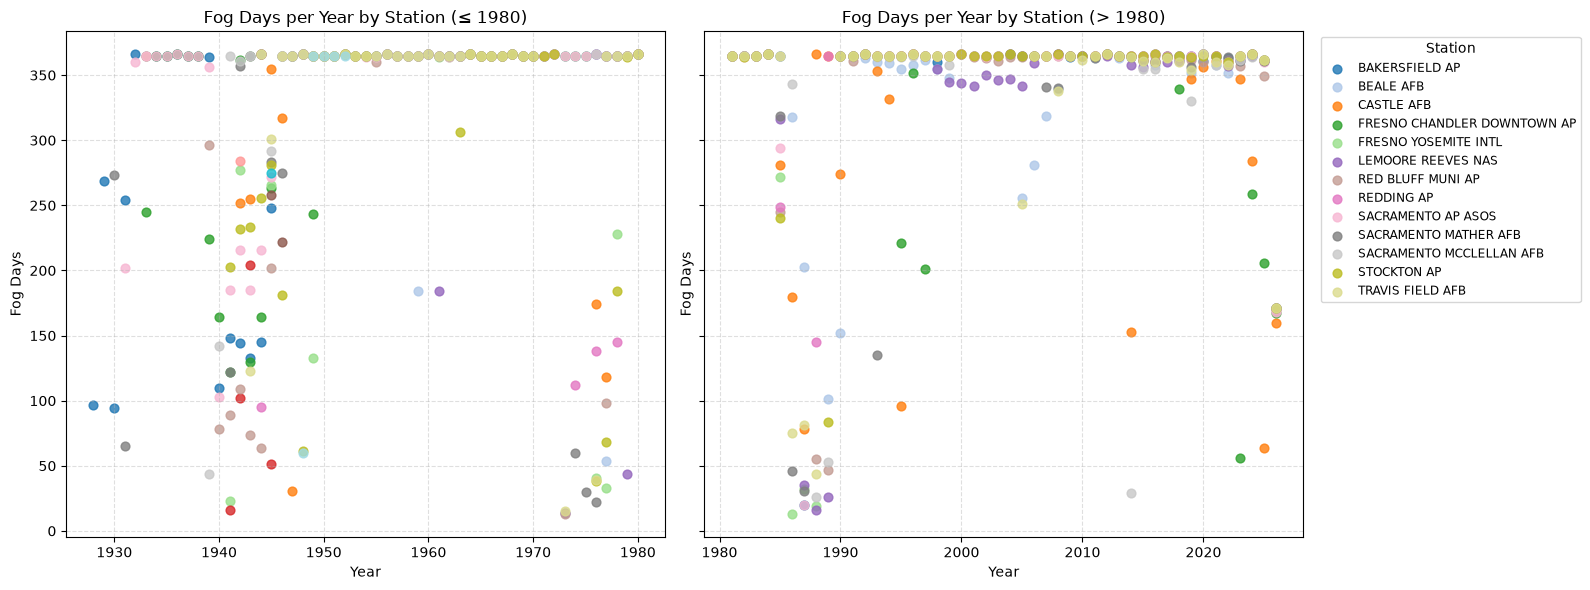

In [41]:
plot_stations = [st for st in stations_pre1970 if st in fog_days_year['STATION'].unique()]
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
color_map = dict(zip(plot_stations, colors))

fog_pre1970 = fog_days_year[fog_days_year['STATION'].isin(plot_stations)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations:
    station_df = fog_pre1970[fog_pre1970['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980)')
axes[1].set_title('Fog Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

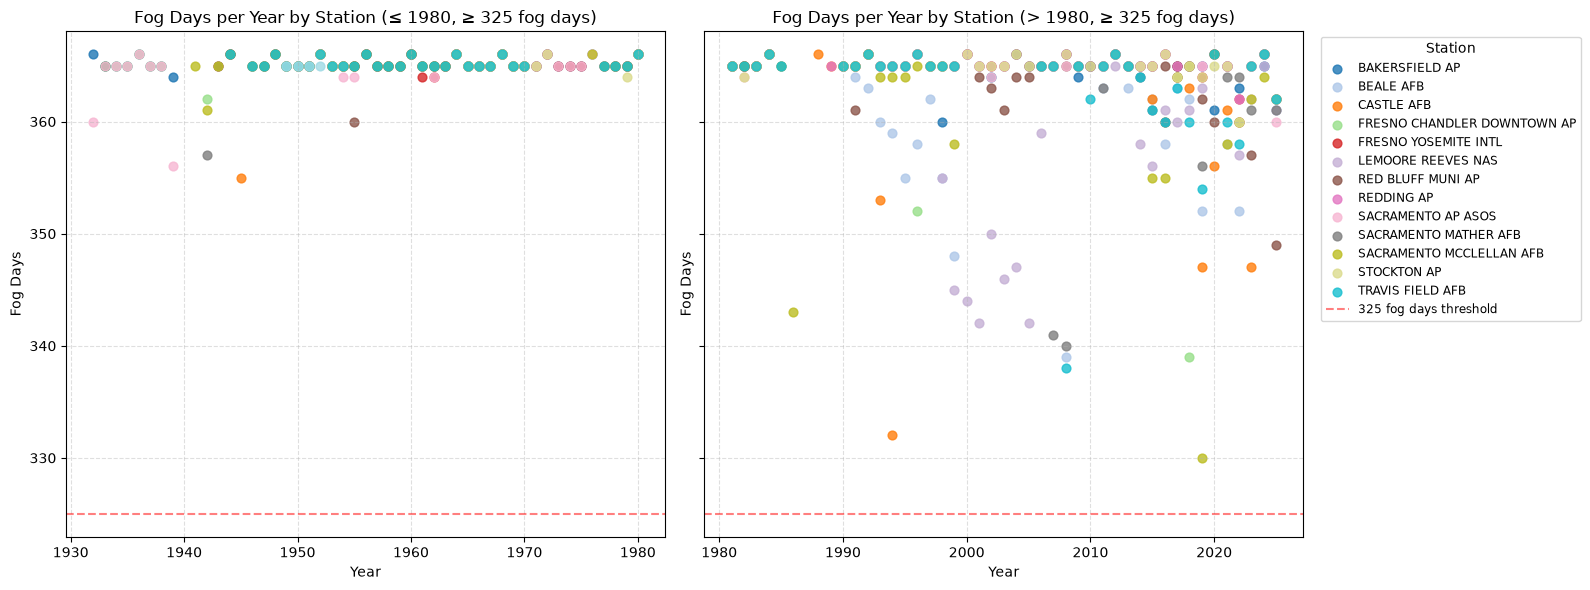

Stations with >= 325 fog days: 16
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'WILLIAMS CAA AIRPORT']


In [45]:
# Remove stations with less than 325 fog days counted
fog_days_year_filtered = fog_days_year[fog_days_year['fog_days'] >= 325]

# Get the filtered list of stations
filtered_plot_stations = [st for st in plot_stations if st in fog_days_year_filtered['STATION'].unique()]

# Create color map for filtered stations
colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# Filter fog data for pre-1970 stations with >= 325 fog days
fog_pre1970_filtered = fog_days_year_filtered[fog_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in filtered_plot_stations:
    station_df = fog_pre1970_filtered[fog_pre1970_filtered['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980, ≥ 325 fog days)')
axes[1].set_title('Fog Days per Year by Station (> 1980, ≥ 325 fog days)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=325, color='red', linestyle='--', alpha=0.5, label='325 fog days threshold')

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

print(f"Stations with >= 325 fog days: {len(filtered_plot_stations)}")
print(filtered_plot_stations)

In [52]:
CV_rows_filtered = CV_rows[CV_rows["STATION"].isin(filtered_plot_stations)].copy()
print("CV_rows_filtered:", CV_rows_filtered.shape)
CV_rows_filtered.head()

CV_rows_filtered: (7787541, 12)


,STATION,year,STATION_ID,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,month,day,hour,minute
0,BAKERSFIELD AP,1928,USW00023155,35.4344,-119.0542,1928-01-01 01:00:00,0.0,8.0,1,1,1,0
1,BAKERSFIELD AP,1928,USW00023155,35.4344,-119.0542,1928-01-01 04:00:00,0.0,8.0,1,1,4,0
2,BAKERSFIELD AP,1928,USW00023155,35.4344,-119.0542,1928-01-01 07:00:00,0.0,0.8,1,1,7,0
3,BAKERSFIELD AP,1928,USW00023155,35.4344,-119.0542,1928-01-01 08:00:00,0.0,0.8,1,1,8,0
4,BAKERSFIELD AP,1928,USW00023155,35.4344,-119.0542,1928-01-01 10:00:00,0.0,8.0,1,1,10,0


In [53]:
# remove rows where HourlyVisibility is zero or missing
CV_rows_filtered = CV_rows_filtered[CV_rows_filtered["HourlyVisibility"].gt(0)]

print("CV_rows_filtered:", CV_rows_filtered.shape)

CV_rows_filtered: (7787541, 12)


In [57]:
#filtering based on precipitation and visibility thresholds
CVf_fog_rows = CV_rows_filtered[
    (CV_rows_filtered["HourlyPrecipitation"] < 0.03)
    & (CV_rows_filtered["HourlyVisibility"] < 100.000)
]

print("CVf_fog_rows:", CVf_fog_rows.shape)

CVf_fog_rows: (7432226, 12)


In [58]:
#counting fog days per year per station
ffog_days_year = (
    CVf_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(ffog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        97
1  BAKERSFIELD AP  1929       269
2  BAKERSFIELD AP  1930        94
3  BAKERSFIELD AP  1931       254
4  BAKERSFIELD AP  1932       366


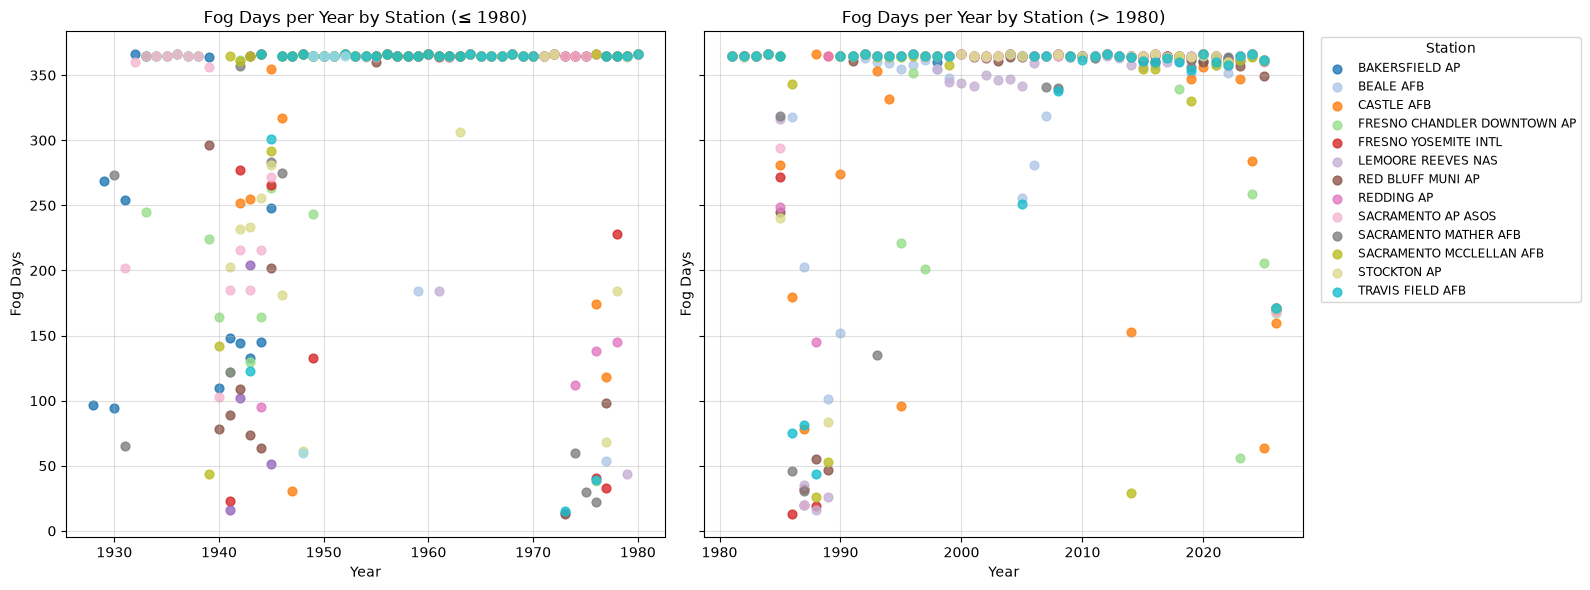

In [59]:
#define stations to plot
plotf_stations = ffog_days_year['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(plotf_stations)))
color_map = dict(zip(plotf_stations, colors))


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plotf_stations:
    station_dff = ffog_days_year[ffog_days_year['STATION'] == station].sort_values('year')
    pre_dff = station_dff[station_dff['year'] <= 1980]
    post_dff = station_dff[station_dff['year'] > 1980]

    if not pre_dff.empty:
        axes[0].scatter(
            pre_dff['year'],
            pre_dff['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_dff.empty:
        axes[1].scatter(
            post_dff['year'],
            post_dff['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980)')
axes[1].set_title('Fog Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, alpha=0.4)

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [60]:
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] >= 300].copy()

valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_fog_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 1038
CV_fog_rows_no_outliers: (9621737, 12)


In [62]:
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1]
print("CV_fog_rows_no_outliers with HourlyVisibility < 1:", low_vis_rows.shape)
low_vis_rows.head()

CV_fog_rows_no_outliers with HourlyVisibility < 1: (193990, 12)


,STATION,year,STATION_ID,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,month,day,hour,minute
188,BAKERSFIELD AP,1932,USW00023155,35.4344,-119.0542,1932-01-09 03:00:00,0.0,0.2,1,9,3,0
189,BAKERSFIELD AP,1932,USW00023155,35.4344,-119.0542,1932-01-09 04:00:00,0.0,0.8,1,9,4,0
190,BAKERSFIELD AP,1932,USW00023155,35.4344,-119.0542,1932-01-09 05:00:00,0.0,0.4,1,9,5,0
191,BAKERSFIELD AP,1932,USW00023155,35.4344,-119.0542,1932-01-09 06:00:00,0.0,0.8,1,9,6,0
202,BAKERSFIELD AP,1932,USW00023155,35.4344,-119.0542,1932-01-10 03:00:00,0.0,0.2,1,10,3,0


In [72]:
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [73]:
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (833, 3)


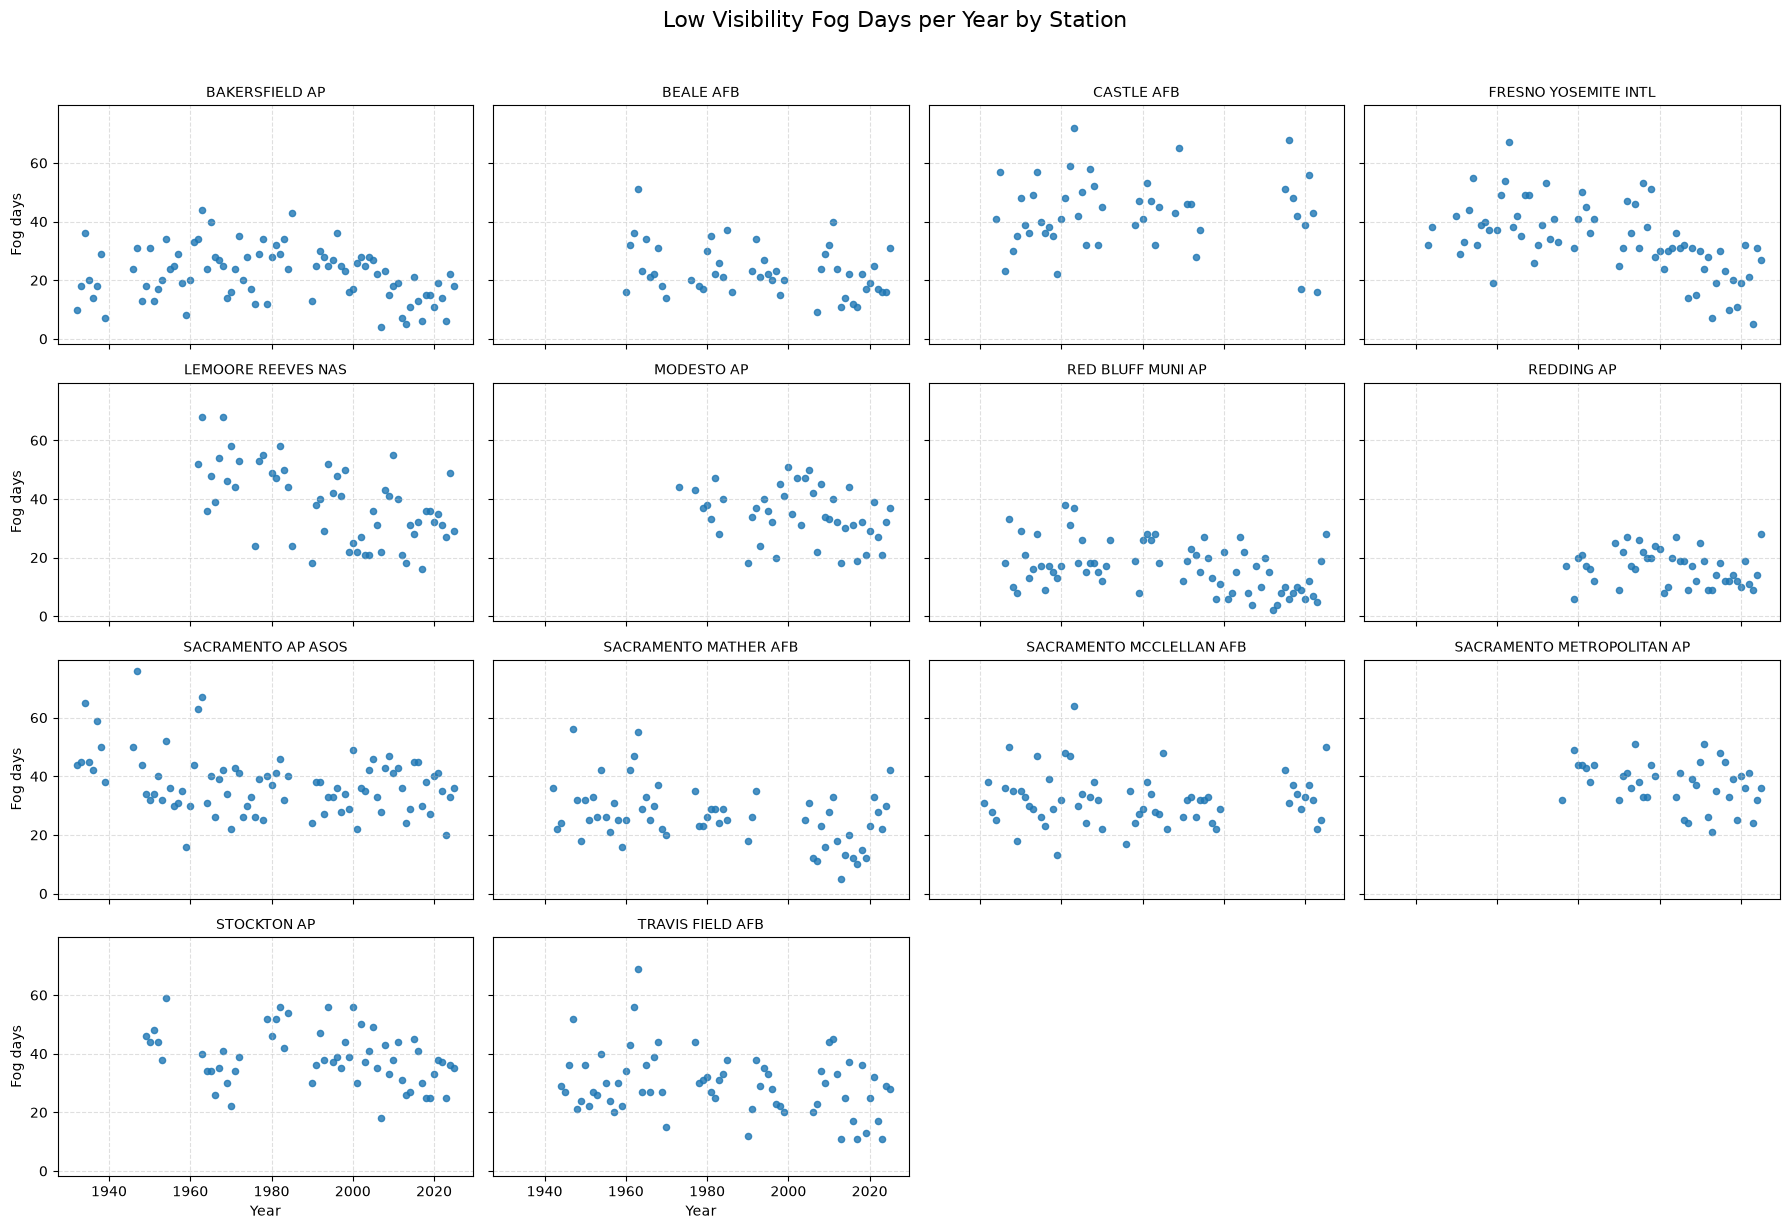

In [75]:

stations = low_vis_fog_days_year_filtered['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [76]:
trend_stats_low_vis = []

for station, station_df in low_vis_fog_days_year.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis = pd.DataFrame(trend_stats_low_vis).sort_values("p_value")

print("Low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis = trend_stats_low_vis[trend_stats_low_vis["trend_significant"]]
print(f"\nStations with significant low-visibility fog-day trends: {len(significant_low_vis)}")
print(significant_low_vis[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis = (
    low_vis_fog_days_year
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis = smf.ols("fog_days ~ year", data=annual_low_vis).fit()

print("\nAnnual aggregated low-visibility fog-day trend summary:")
print(model_annual_low_vis.summary())

Low-visibility fog-day trend statistics by station:
                        STATION  n_obs  min_year  max_year     slope  \
5          FRESNO YOSEMITE INTL     70      1943      2025 -0.284902   
7            LEMOORE REEVES NAS     56      1962      2025 -0.384843   
10    MARYSVILLE AIRPORT (ASOS)     19      2005      2025 -1.130761   
14            RED BLUFF MUNI AP     70      1946      2025 -0.140626   
17        SACRAMENTO MATHER AFB     61      1942      2025 -0.150014   
6          HANFORD MUNICIPAL AP     21      2005      2025 -1.298701   
16           SACRAMENTO AP ASOS     83      1932      2025 -0.123095   
20                  STOCKTON AP     58      1949      2025 -0.122237   
1                     BEALE AFB     49      1960      2025 -0.131709   
21             TRAVIS FIELD AFB     66      1944      2025 -0.114869   
0                BAKERSFIELD AP     84      1932      2025 -0.076860   
19   SACRAMENTO METROPOLITAN AP     39      1976      2025 -0.164190   
12          

In [77]:
# Filter for low visibility fog days after 1980
post1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] >= 1980].copy()

trend_stats_low_vis_post1980 = []

for station, station_df in post1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980 = pd.DataFrame(trend_stats_low_vis_post1980).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980 = trend_stats_low_vis_post1980[trend_stats_low_vis_post1980["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980)}")
print(significant_low_vis_post1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980 = (
    post1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980 = smf.ols("fog_days ~ year", data=annual_low_vis_post1980).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
0               BAKERSFIELD AP     42      1980      2025 -0.461675  0.078275   
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.621237  0.105596   
12                 STOCKTON AP     41      1980      2025 -0.395599  0.096472   
6            RED BLUFF MUNI AP     41      1980      2025 -0.332091  0.083260   
4           LEMOORE REEVES NAS     42      1980      2025 -0.291976  0.127948   
1                    BEALE AFB     35      1980      2025 -0.181692  0.086352   
7                   REDDING AP     42      1980      2025 -0.136367  0.068051   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.177202  0.089240   
5                   MODESTO AP     41      1980      2025 -0.152616  0.110207   
13            TRAVIS FIELD AFB     36      1980      2025 -0.133569  0.107950   
9        SACRAMENTO MATHER AFB     31      1980

In [67]:
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

plot_stations = low_vis_fog_days_year['STATION'].unique()
cmap = plt.cm.get_cmap('tab20', len(plot_stations))
color_map = dict(zip(plot_stations, cmap(range(len(plot_stations)))))

fig, ax = plt.subplots(figsize=(14, 6))
for station in plot_stations:
    station_df = low_vis_fog_days_year[low_vis_fog_days_year['STATION'] == station]
    ax.scatter(
        station_df['year'],
        station_df['fog_days'],
        label=station,
        color=color_map[station],
        s=30,
        alpha=0.8
    )

ax.set_title('Low Visibility Fog Days per Year by Station')
ax.set_xlabel('Year')
ax.set_ylabel('Fog Days (HourlyVisibility < 1)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

AttributeError: module 'matplotlib.cm' has no attribute 'get_cmap'

Rows with HourlyVisibility < 1: (193990, 12)
            STATION  year                 DATE  HourlyVisibility
188  BAKERSFIELD AP  1932  1932-01-09 03:00:00               0.2
189  BAKERSFIELD AP  1932  1932-01-09 04:00:00               0.8
190  BAKERSFIELD AP  1932  1932-01-09 05:00:00               0.4
191  BAKERSFIELD AP  1932  1932-01-09 06:00:00               0.8
202  BAKERSFIELD AP  1932  1932-01-10 03:00:00               0.2


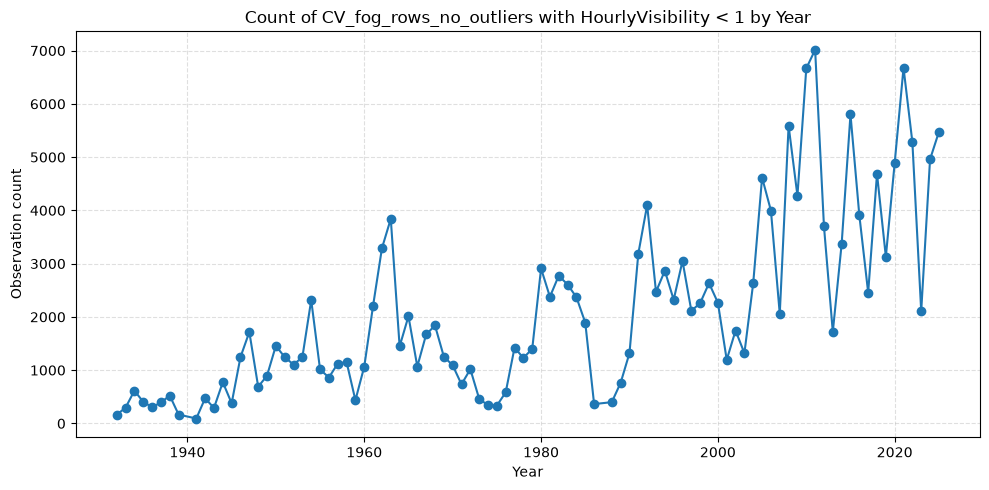

In [ ]:
ow

In [42]:
post1980_pre1970 = fog_days_year[
    (fog_days_year["year"] > 1980)
    & (fog_days_year["STATION"].isin(stations_pre1970))
].copy()

station_trend_stats_1980 = []

for station, station_df in post1980_pre1970.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    station_trend_stats_1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

station_trend_stats_1980 = pd.DataFrame(station_trend_stats_1980).sort_values("p_value")

print("Post-1980 fog-day trend statistics for stations_pre1970:")
print(station_trend_stats_1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

significant_post1980_pre1970 = station_trend_stats_1980[
    station_trend_stats_1980["trend_significant"]
]
print("\nStations with significant post-1980 fog-day trends:")
print(significant_post1980_pre1970[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

Post-1980 fog-day trend statistics for stations_pre1970:
                        STATION  n_obs  min_year  max_year     slope  \
4          FRESNO YOSEMITE INTL     45      1981      2026  1.860257   
9         SACRAMENTO MATHER AFB     34      1981      2026  1.701846   
5            LEMOORE REEVES NAS     45      1981      2026  1.595253   
12             TRAVIS FIELD AFB     40      1981      2026  1.283651   
6             RED BLUFF MUNI AP     44      1981      2026  0.977269   
1                     BEALE AFB     40      1981      2026  0.699423   
3   FRESNO CHANDLER DOWNTOWN AP      8      1995      2026 -2.402661   
8            SACRAMENTO AP ASOS     43      1981      2026  0.422164   
11                  STOCKTON AP     43      1981      2026  0.353302   
2                    CASTLE AFB     28      1981      2026 -0.498758   
7                    REDDING AP     44      1981      2026  0.199721   
0                BAKERSFIELD AP     43      1981      2026  0.242762   
10     

In [43]:
post1980_all = fog_days_year[fog_days_year["year"] > 1980].copy()

station_trend_stats_all = []

for station, station_df in post1980_all.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    station_trend_stats_all.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

station_trend_stats_all = pd.DataFrame(station_trend_stats_all).sort_values("p_value")

print("Post-1980 fog-day trend statistics for all stations:")
print(station_trend_stats_all[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

significant_post1980_all = station_trend_stats_all[
    station_trend_stats_all["trend_significant"]
]
print("\nStations with significant post-1980 fog-day trends (all stations):")
print(significant_post1980_all[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

Post-1980 fog-day trend statistics for all stations:
                        STATION  n_obs  min_year  max_year     slope  \
5          FRESNO YOSEMITE INTL     45      1981      2026  1.860257   
13        OROVILLE MUNICIPAL AP     22      2005      2026 -2.448899   
6          HANFORD MUNICIPAL AP     22      2005      2026 -2.407115   
8        LIVERMORE MUNICIPAL AP     27      2000      2026 -1.589133   
9           MADERA MUNICIPAL AP     22      2005      2026 -2.564653   
11          MERCED MUNICIPAL AP     22      2005      2026 -2.392434   
18        SACRAMENTO MATHER AFB     34      1981      2026  1.701846   
7            LEMOORE REEVES NAS     45      1981      2026  1.595253   
22             TRAVIS FIELD AFB     40      1981      2026  1.283651   
24         VISALIA MUNICIPAL AP     22      2005      2026 -1.848108   
20   SACRAMENTO METROPOLITAN AP     40      1981      2026  1.206085   
14            RED BLUFF MUNI AP     44      1981      2026  0.977269   
1          

In [44]:
# Filter for visibility over 100
high_visibility = CV_fog_rows[CV_fog_rows["HourlyVisibility"] > 100]

print(high_visibility)

Empty DataFrame
Columns: [STATION, year, STATION_ID, LATITUDE, LONGITUDE, DATE, HourlyPrecipitation, HourlyVisibility, month, day, hour, minute]
Index: []
